In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [200]:
df=pd.read_csv('purchase_data.csv')
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10.0,A,2,0.0,3.0,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10.0,A,2,0.0,1.0,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10.0,A,2,0.0,12.0,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10.0,A,2,0.0,12.0,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16.0,C,4+,0.0,8.0,NaN,NaN,7969.0
...,...,...,...,...,...,...,...,...,...,...,...,...
263010,1004473,P00041942,M,36-45,1.0,B,3,0.0,5.0,18.0,NaN,3722.0
263011,1004473,P00115142,M,36-45,1.0,B,3,0.0,1.0,8.0,17.0,19253.0
263012,1004473,P00188442,M,36-45,1.0,B,3,0.0,5.0,7.0,NaN,3608.0
263013,1004473,P00119442,M,36-45,1.0,B,3,0.0,5.0,NaN,NaN,3604.0


#EDA : Exploratory Data Analysis
##1. null values
##2. duplicate values
##3. outliers
##4. label encoding

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263015 entries, 0 to 263014
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263015 non-null  int64  
 1   Product_ID                  263014 non-null  object 
 2   Gender                      263014 non-null  object 
 3   Age                         263014 non-null  object 
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  object 
 6   Stay_In_Current_City_Years  263014 non-null  object 
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          181501 non-null  float64
 10  Product_Category_3          80582 non-null   float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(6), int64(1), object(5)
memory usage: 24.1+ MB


In [202]:
df.isnull().sum()

,0
User_ID,0
Product_ID,1
Gender,1
Age,1
Occupation,1
City_Category,1
Stay_In_Current_City_Years,1
Marital_Status,1
Product_Category_1,1
Product_Category_2,81514


In [203]:
df.duplicated().sum()

np.int64(0)

In [204]:
#lets pretend we had duplicate values
# df.drop_duplicates(inplace=True)

In [205]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0', nan], dtype=object)

In [206]:
df['Stay_In_Current_City_Years'].replace("4+","4", inplace=True)

/tmp/ipython-input-1504064745.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Stay_In_Current_City_Years'].replace("4+","4", inplace=True)


In [207]:
df[['Stay_In_Current_City_Years']]=df[['Stay_In_Current_City_Years']].fillna('0')

In [208]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4', '3', '1', '0'], dtype=object)

In [209]:
df[['Stay_In_Current_City_Years']]=df[['Stay_In_Current_City_Years']].astype(int)

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263015 entries, 0 to 263014
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263015 non-null  int64  
 1   Product_ID                  263014 non-null  object 
 2   Gender                      263014 non-null  object 
 3   Age                         263014 non-null  object 
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  object 
 6   Stay_In_Current_City_Years  263015 non-null  int64  
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          181501 non-null  float64
 10  Product_Category_3          80582 non-null   float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 24.1+ MB


In [211]:
df[['Product_Category_2','Product_Category_3']]=df[['Product_Category_2','Product_Category_3']].fillna(0.0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263015 entries, 0 to 263014
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263015 non-null  int64  
 1   Product_ID                  263014 non-null  object 
 2   Gender                      263014 non-null  object 
 3   Age                         263014 non-null  object 
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  object 
 6   Stay_In_Current_City_Years  263015 non-null  int64  
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          263015 non-null  float64
 10  Product_Category_3          263015 non-null  float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 24.1+ MB


In [212]:
df[['Product_Category_2','Product_Category_3']]=df[['Product_Category_2','Product_Category_3']].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263015 entries, 0 to 263014
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263015 non-null  int64  
 1   Product_ID                  263014 non-null  object 
 2   Gender                      263014 non-null  object 
 3   Age                         263014 non-null  object 
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  object 
 6   Stay_In_Current_City_Years  263015 non-null  int64  
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          263015 non-null  int64  
 10  Product_Category_3          263015 non-null  int64  
 11  Purchase                    263014 non-null  float64
dtypes: float64(4), int64(4), object(4)
memory usage: 24.1+ MB


In [213]:
df.isnull().sum()

,0
User_ID,0
Product_ID,1
Gender,1
Age,1
Occupation,1
City_Category,1
Stay_In_Current_City_Years,0
Marital_Status,1
Product_Category_1,1
Product_Category_2,0


In [214]:
df.dropna(inplace=True)
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,0


In [215]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

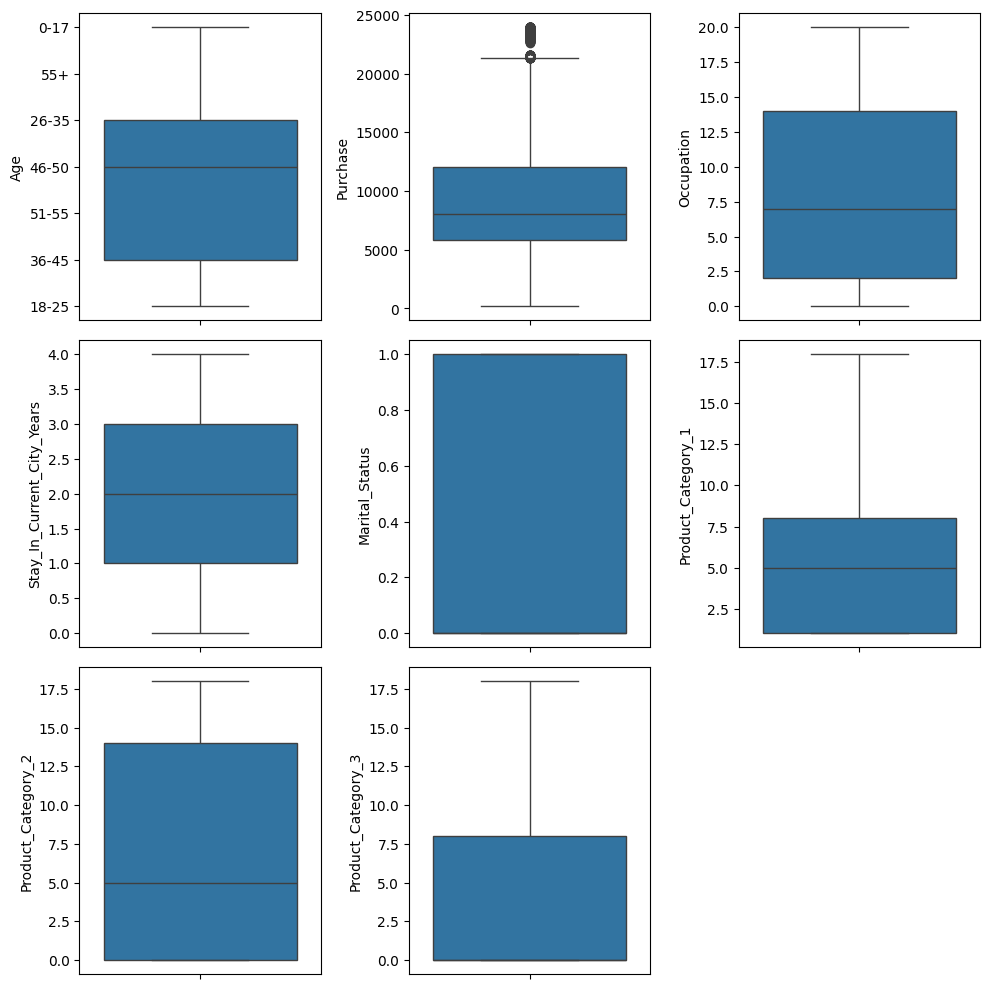

In [216]:
#boxplots

plt.figure(figsize=(10,10))

plt.subplot(3,3,1)
sns.boxplot(df['Age'])

plt.subplot(3,3,2)
sns.boxplot(df['Purchase'])

plt.subplot(3,3,3)
sns.boxplot(df['Occupation'])

plt.subplot(3,3,4)
sns.boxplot(df['Stay_In_Current_City_Years'])

plt.subplot(3,3,5)
sns.boxplot(df['Marital_Status'])

plt.subplot(3,3,6)
sns.boxplot(df['Product_Category_1'])

plt.subplot(3,3,7)
sns.boxplot(df['Product_Category_2'])

plt.subplot(3,3,8)
sns.boxplot(df['Product_Category_3'])

plt.tight_layout()
plt.show()

In [217]:
Q1=df['Purchase'].quantile(0.25)
Q3=df['Purchase'].quantile(0.75)
IQR=Q3-Q1

lb=Q1-1.5*IQR
ub=Q3+1.5*IQR

df=df[(df['Purchase']>=lb) & (df['Purchase']<=ub)]

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 261725 entries, 0 to 263013
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     261725 non-null  int64  
 1   Product_ID                  261725 non-null  object 
 2   Gender                      261725 non-null  object 
 3   Age                         261725 non-null  object 
 4   Occupation                  261725 non-null  float64
 5   City_Category               261725 non-null  object 
 6   Stay_In_Current_City_Years  261725 non-null  int64  
 7   Marital_Status              261725 non-null  float64
 8   Product_Category_1          261725 non-null  float64
 9   Product_Category_2          261725 non-null  int64  
 10  Product_Category_3          261725 non-null  int64  
 11  Purchase                    261725 non-null  float64
dtypes: float64(4), int64(4), object(4)
memory usage: 26.0+ MB


In [219]:
#Label Encoding : conversion of object data to numeric

cols=['Gender','Age','City_Category','Product_ID']

In [220]:
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [221]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder() #le is the instance : example - class and object

for col in cols:
  df[col]=le.fit_transform(df[col])
  print(f"Column:{col}")
  #to find which number has been assigned to which category
  for code, category in enumerate(le.classes_): #enumerate: built-in functions that takes an iterable(like a list) and returns a pair of index,value
    #le.classes_ has unique categories in sorted alphabetical manner
    print(f"{category}->{code}")
  print() #for a blank line

Column:Gender
F->0
M->1

Column:Age
0-17->0
18-25->1
26-35->2
36-45->3
46-50->4
51-55->5
55+->6

Column:City_Category
A->0
B->1
C->2

Column:Product_ID
P00000142->0
P00000242->1
P00000342->2
P00000442->3
P00000542->4
P00000642->5
P00000742->6
P00000842->7
P00000942->8
P00001042->9
P00001142->10
P00001242->11
P00001342->12
P00001442->13
P00001542->14
P00001642->15
P00001742->16
P00001842->17
P00001942->18
P00002042->19
P00002142->20
P00002242->21
P00002342->22
P00002442->23
P00002542->24
P00002642->25
P00002742->26
P00002842->27
P00002942->28
P00003042->29
P00003142->30
P00003242->31
P00003342->32
P00003442->33
P00003542->34
P00003642->35
P00003742->36
P00003842->37
P00003942->38
P00004042->39
P00004142->40
P00004242->41
P00004342->42
P00004442->43
P00004542->44
P00004642->45
P00004742->46
P00004842->47
P00004942->48
P00005042->49
P00005142->50
P00005242->51
P00005342->52
P00005442->53
P00005542->54
P00005642->55
P00005742->56
P00005842->57
P00005942->58
P00006042->59
P00006142->60
P000

/tmp/ipython-input-3402864078.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=le.fit_transform(df[col])
/tmp/ipython-input-3402864078.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=le.fit_transform(df[col])
/tmp/ipython-input-3402864078.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 261725 entries, 0 to 263013
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     261725 non-null  int64  
 1   Product_ID                  261725 non-null  int64  
 2   Gender                      261725 non-null  int64  
 3   Age                         261725 non-null  int64  
 4   Occupation                  261725 non-null  float64
 5   City_Category               261725 non-null  int64  
 6   Stay_In_Current_City_Years  261725 non-null  int64  
 7   Marital_Status              261725 non-null  float64
 8   Product_Category_1          261725 non-null  float64
 9   Product_Category_2          261725 non-null  int64  
 10  Product_Category_3          261725 non-null  int64  
 11  Purchase                    261725 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 26.0 MB


In [223]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,647,0,0,10.0,0,2,0.0,3.0,0,0,8370.0
1,1000001,2304,0,0,10.0,0,2,0.0,1.0,6,14,15200.0
2,1000001,814,0,0,10.0,0,2,0.0,12.0,0,0,1422.0
3,1000001,790,0,0,10.0,0,2,0.0,12.0,14,0,1057.0
4,1000002,2657,1,6,16.0,2,4,0.0,8.0,0,0,7969.0
...,...,...,...,...,...,...,...,...,...,...,...,...
263009,1004473,2762,1,3,1.0,1,3,0.0,8.0,0,0,8061.0
263010,1004473,403,1,3,1.0,1,3,0.0,5.0,18,0,3722.0
263011,1004473,1015,1,3,1.0,1,3,0.0,1.0,8,17,19253.0
263012,1004473,1717,1,3,1.0,1,3,0.0,5.0,7,0,3608.0


# Statistic Analysis

1) Preparing sample

2) Creating two hypothesis ( null hypothesis , Alternate hypothesis )

3) Applying the appropriate test ( based on requirement or case )

4) Compare the p_value

if **p_value is > 0.05** = Fail to reject the null hypothesis ( Accept null hypothesis )

if **p_value is < 0.05** = Reject the null hypothesis ( Accept the alternate hypothesis )


# a) It was observed that the average purchase made by the Men of the age 18-25 was 10000. Is it still the same?

In [224]:
#Extract the data of age group 18-25

new_data=df[(df['Age']==1) & (df['Gender']==1)]
new_data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
97,1000021,2024,1,1,16.0,1,0,0.0,3.0,12,0,3055.0
98,1000022,3261,1,1,15.0,0,4,0.0,1.0,8,17,12099.0
99,1000022,1954,1,1,15.0,0,4,0.0,5.0,8,0,8797.0
100,1000022,1792,1,1,15.0,0,4,0.0,3.0,4,0,10681.0
101,1000022,1020,1,1,15.0,0,4,0.0,8.0,14,0,7801.0
...,...,...,...,...,...,...,...,...,...,...,...,...
262767,1004446,1311,1,1,18.0,1,1,1.0,1.0,2,0,15431.0
262951,1004465,2880,1,1,4.0,0,1,1.0,5.0,0,0,1763.0
262952,1004465,1296,1,1,4.0,0,1,1.0,2.0,3,4,3240.0
262953,1004465,2733,1,1,4.0,0,1,1.0,8.0,0,0,5832.0


In [225]:
#Collect sample population

sample=new_data.sample(3600, random_state=5)
sample

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
207830,1002010,410,1,1,4.0,1,0,0.0,5.0,14,0,5430.0
18139,1002859,1141,1,1,1.0,2,0,0.0,1.0,2,15,15448.0
46341,1001138,973,1,1,12.0,2,4,0.0,1.0,2,0,19259.0
203994,1001470,141,1,1,4.0,0,1,1.0,1.0,2,5,15222.0
3206,1000524,2478,1,1,0.0,0,0,0.0,8.0,13,14,2213.0
...,...,...,...,...,...,...,...,...,...,...,...,...
173759,1002894,2310,1,1,4.0,1,4,0.0,1.0,5,15,8096.0
74445,1005482,795,1,1,7.0,0,1,0.0,2.0,4,8,13029.0
37813,1005824,511,1,1,12.0,1,1,0.0,10.0,15,0,14128.0
118037,1000202,2818,1,1,4.0,0,3,0.0,8.0,0,0,7885.0


In [226]:
#manually checking the null hypothesis

new_data['Purchase'].mean()

np.float64(9391.676371471189)

In [227]:
#Null hypothesis = mean will be 10000
#Alternate hypothesis = mean will not be 10000

In [228]:
from scipy.stats import ttest_1samp

a_mean=10000

In [229]:
t_stat,p_value=ttest_1samp(sample['Purchase'],a_mean)
print(t_stat, p_value)

-6.032597834091577 1.7766468838738448e-09


In [230]:
value= 1.7766468838738448e-09
print(f"{value: .25f}") #less than 0.05

 0.0000000017766468838738448


In [231]:
#REJECTING THE NULL HYPOTHESIS



---



# b) It was observed that the percentage of women that spend more than 10000 was 35%. Is it still the same?

In [232]:
#null hypothesis: proportion is 35%
#alternate hypothesis: proportion is not 35%

In [233]:
#Extract the data of all spenders above 10000

new_data=df[(df['Purchase']>10000)]
new_data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
1,1000001,2304,0,0,10.0,0,2,0.0,1.0,6,14,15200.0
5,1000003,1768,1,2,15.0,0,3,0.0,1.0,2,0,15227.0
6,1000004,1684,1,4,7.0,1,2,1.0,1.0,8,17,19215.0
7,1000004,3213,1,4,7.0,1,2,1.0,1.0,15,0,15854.0
8,1000004,3481,1,4,7.0,1,2,1.0,1.0,16,0,15686.0
...,...,...,...,...,...,...,...,...,...,...,...,...
262997,1004472,2433,0,4,16.0,1,0,1.0,1.0,11,16,15175.0
263001,1004472,1921,0,4,16.0,1,0,1.0,1.0,11,15,15430.0
263002,1004472,1665,0,4,16.0,1,0,1.0,15.0,16,0,12567.0
263003,1004472,3209,0,4,16.0,1,0,1.0,1.0,2,15,15387.0


In [234]:
new_data['Gender'].value_counts()

,count
Gender,
1,71366
0,18402


In [235]:
#number of women in the sample
count=new_data['Gender'].value_counts()[0]

#number of observations
nobs=len(new_data['Gender'])

#hypothesis value
p0=0.35

In [236]:
count,nobs,p0

(np.int64(18402), 89768, 0.35)

In [237]:
18402/89768

0.20499509847607164

In [238]:
from statsmodels.stats.proportion import proportions_ztest

z_stat,p_value=proportions_ztest(count=count,nobs=nobs,value=p0)
print(z_stat,p_value)

-107.61847057425669 0.0


In [239]:
#REJECTING THE NULL HYPOTHESIS

**z-statistic**: Measures how many standard errors the observed proportion is away from the hypothesized proportion of 35%.

**p-value**: If the p-value is less than 0.05, reject the null hypothesis and conclude that the proportion of women spending more than 10,000 is different from 35%.

# c)  Is the percentage of men who have spent more than 10000 the same for the ages 18-25 and 26-35?

To determine if the percentage of men who spent more than 10,000 is the same for the age groups 18-25 and 26-35, we can perform an inferential statistical test, specifically a **two-proportion z-test.** This test will help us check if the difference in proportions of men with purchases over 10,000 in the two age groups is statistically significant.

In [240]:
#null hypothesis: proportion is 50%
#alternate hypothesis: proportion is not 50%

In [256]:
new_data=df[(df['Purchase']>10000) & (df['Gender']==1) & (df['Age']==1)]
new_data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
98,1000022,3261,1,1,15.0,0,4,0.0,1.0,8,17,12099.0
100,1000022,1792,1,1,15.0,0,4,0.0,3.0,4,0,10681.0
102,1000022,3490,1,1,15.0,0,4,0.0,1.0,16,0,15517.0
103,1000022,2433,1,1,15.0,0,4,0.0,1.0,11,16,12098.0
127,1000025,1891,1,1,4.0,2,4,0.0,1.0,5,9,15361.0
...,...,...,...,...,...,...,...,...,...,...,...,...
262758,1004446,1138,1,1,18.0,1,1,1.0,1.0,2,15,11512.0
262759,1004446,2312,1,1,18.0,1,1,1.0,1.0,15,18,11521.0
262762,1004446,1152,1,1,18.0,1,1,1.0,1.0,11,0,11894.0
262763,1004446,998,1,1,18.0,1,1,1.0,3.0,5,0,10894.0


In [257]:
new_data2=df[(df['Purchase']>10000) & (df['Gender']==1) & (df['Age']==2)]
new_data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
98,1000022,3261,1,1,15.0,0,4,0.0,1.0,8,17,12099.0
100,1000022,1792,1,1,15.0,0,4,0.0,3.0,4,0,10681.0
102,1000022,3490,1,1,15.0,0,4,0.0,1.0,16,0,15517.0
103,1000022,2433,1,1,15.0,0,4,0.0,1.0,11,16,12098.0
127,1000025,1891,1,1,4.0,2,4,0.0,1.0,5,9,15361.0
...,...,...,...,...,...,...,...,...,...,...,...,...
262758,1004446,1138,1,1,18.0,1,1,1.0,1.0,2,15,11512.0
262759,1004446,2312,1,1,18.0,1,1,1.0,1.0,15,18,11521.0
262762,1004446,1152,1,1,18.0,1,1,1.0,1.0,11,0,11894.0
262763,1004446,998,1,1,18.0,1,1,1.0,3.0,5,0,10894.0


In [262]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# assume your DataFrame is df with columns: 'Purchase', 'gender', 'Age'
men = df[df['Gender'] == 1].copy()

# outcome indicator: spent > 10000
men['gt10k'] = (men['Purchase'] > 10000)

# counts for each age group
g1 = men[men['Age'] == 1]   # 18–25
g2 = men[men['Age'] == 2]   # 26–35

x1 = g1['gt10k'].sum()      # number who spent > 10k in group 1
n1 = g1['gt10k'].count()    # total men in group 1

x2 = g2['gt10k'].sum()      # number who spent > 10k in group 2
n2 = g2['gt10k'].count()    # total men in group 2

# two-proportion z-test (pooled)
z_stat, p_val = proportions_ztest(count=[x1, x2], nobs=[n1, n2], alternative='two-sided')

# 95% CIs for each group (Wilson is a good default)
ci1 = proportion_confint(count=x1, nobs=n1, alpha=0.05, method='wilson')
ci2 = proportion_confint(count=x2, nobs=n2, alpha=0.05, method='wilson')

p1 = x1 / n1
p2 = x2 / n2
diff = p1 - p2

print(f"x1={x1}, n1={n1}, p1={p1:.3f}, CI1={ci1}")
print(f"x2={x2}, n2={n2}, p2={p2:.3f}, CI2={ci2}")
print(f"Difference (p1 - p2) = {diff:.3f}")
print(f"z = {z_stat:.3f}, p-value = {p_val:.4f}")


x1=13195, n1=36202, p1=0.364, CI1=(0.35953950371582066, 0.36945450375228805)
x2=29177, n2=80637, p2=0.362, CI2=(0.35852140555727974, 0.3651545928959504)
Difference (p1 - p2) = 0.003
z = 0.872, p-value = 0.3834


Among men, the share spending >10,000 is practically the same for 18–25 and 26–35.


# d) Is the average purchase made by men and women of the age 18-25 same